In [ ]:
from dotenv import load_dotenv
import os
#import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from qTabTransformerCLS import run_experiment, infer_tabtransformer
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# # Set up .env file with Kaggle username and key
# load_dotenv()
# os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
# os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")

# path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
# file = os.path.join(path, 'creditcard.csv')
# data = pd.read_csv(file)

In [ ]:
data = pd.read_csv('fraud_data.csv') #This notebook uses data in same folder, but can use kaggle path too
print(f"# of Frauds = {np.sum(data['Class'])}")
print(np.sum(data['Class'])/len(data['Class'])*100, '%')

# of Frauds = 492
0.1727485630620034 %


In [ ]:
#Split data into fraud and non-fraud to build high concentration of fraud in small training dataset
train_size = 2000
fraud_data = data[data['Class'] == 1].sample(frac=1, random_state=42)
non_fraud_data = data[data['Class'] == 0].sample(frac=1, random_state=42)
data_subset = pd.concat([fraud_data, non_fraud_data[:train_size - len(fraud_data)]]).sample(frac=1, random_state=42)

#Test model on small dataset
model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(data_subset, lr=3e-3)
print(f'Test AUPRC: {test_auprc}')

Epoch 01 | train_loss=0.17758 | val_auprc=0.92516 | val_auroc=0.93323
Epoch 02 | train_loss=0.13716 | val_auprc=0.90309 | val_auroc=0.91093
Epoch 03 | train_loss=0.10890 | val_auprc=0.94911 | val_auroc=0.95391
Epoch 04 | train_loss=0.09472 | val_auprc=0.93999 | val_auroc=0.94513
Epoch 05 | train_loss=0.08568 | val_auprc=0.94778 | val_auroc=0.95310
Epoch 06 | train_loss=0.07846 | val_auprc=0.94755 | val_auroc=0.94864
Epoch 07 | train_loss=0.07609 | val_auprc=0.95168 | val_auroc=0.95351
Epoch 08 | train_loss=0.06964 | val_auprc=0.95784 | val_auroc=0.96270
Epoch 09 | train_loss=0.06634 | val_auprc=0.96166 | val_auroc=0.97067
Epoch 10 | train_loss=0.07767 | val_auprc=0.96490 | val_auroc=0.97540
Epoch 11 | train_loss=0.06731 | val_auprc=0.96680 | val_auroc=0.97770
Epoch 12 | train_loss=0.06294 | val_auprc=0.96750 | val_auroc=0.97783
Epoch 13 | train_loss=0.06198 | val_auprc=0.96486 | val_auroc=0.97594
Epoch 14 | train_loss=0.06040 | val_auprc=0.96450 | val_auroc=0.97594
Epoch 15 | train_los

In [ ]:
#Keep model trained on 2000 data points and calculate test metrics on different sizes of inference data
test_data = data_subset.iloc[np.load('test_inds.npy')]
inference_data = pd.concat([test_data, non_fraud_data[train_size - len(fraud_data):]]).sample(frac=1, random_state=42)
inference_sizes = [2000, 5000, 10000, 50000, 100000, len(inference_data)-2]
inference_auprcs = []

for size in inference_sizes:
    _, inference_subset = train_test_split(inference_data, test_size=size/len(inference_data), stratify=inference_data['Class'], random_state=42)
    results = infer_tabtransformer(model, inference_subset)
    inference_auprcs.append(results['auprc'])
    print(f'Inference Size: {size}')
    print(f'AUPRC: {results["auprc"]}')
    print() #30 min runtime

Inference Size: 2000
AUPRC: 1.0

Inference Size: 5000
AUPRC: 0.25

Inference Size: 10000
AUPRC: 0.24908335827596528

Inference Size: 50000
AUPRC: 0.1969632625779455

Inference Size: 100000
AUPRC: 0.14839702221933077

Inference Size: 283208
AUPRC: 0.23791718840741552



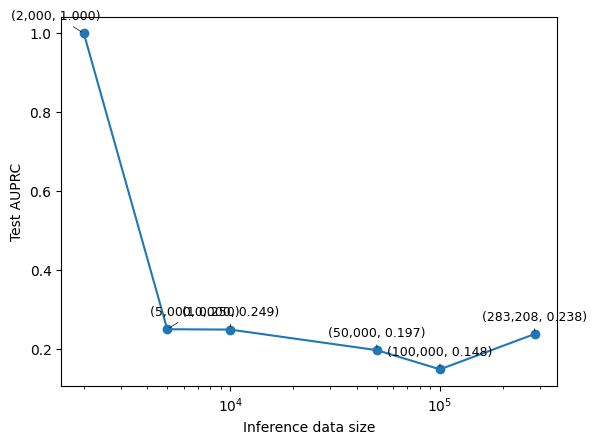

In [ ]:
#Plot auprc vs inference data size
fig, ax = plt.subplots()
ax.plot(inference_sizes, inference_auprcs, marker='o', linestyle='-')
offsets = [
    (-20, 10),
    (20, 10),
    (0, 10),
    (0, 10),
    (0, 10),
    (0, 10),
]

for (xi, yi), (dx, dy) in zip(zip(inference_sizes, inference_auprcs), offsets):
    ax.annotate(
        f"({xi:,}, {yi:.3f})",
        xy=(xi, yi),
        xytext=(dx, dy),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="-", lw=0.5),
        fontsize=9,
        ha="center",
    )
ax.set_xscale("log")
ax.set_xlabel("Inference data size")
ax.set_ylabel("Test AUPRC")
plt.show()

In [ ]:
#Test how different sizes of training data improve generalization to full dataset
train_sizes = [2000, 4000, 6000, 8000, 10000]
train_frauds = 400 #80%, save other 20% for inference
avg_test_auprcs = []
avg_train_routine_auprcs = []

seeds = list(range(5))

for size in train_sizes:

    test_auprcs = []
    train_routine_auprcs = []

    #Average results over several different random seedings to filter out noise
    for seed in seeds:
        fraud_data = data[data['Class'] == 1].sample(frac=1, random_state=seed)
        non_fraud_data = data[data['Class'] == 0].sample(frac=1, random_state=seed)
        train_data = pd.concat([fraud_data[:train_frauds], non_fraud_data[:size - len(fraud_data[:train_frauds])]]).sample(frac=1, random_state=seed)
        test_data = pd.concat([fraud_data[train_frauds:], non_fraud_data[size - len(fraud_data[:train_frauds]):]]).sample(frac=1, random_state=seed)

        model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(train_data, lr=5e-4)
        results = infer_tabtransformer(model, test_data)

        test_auprcs.append(results['auprc'])
        train_routine_auprcs.append(test_auprc)

    avg_test_auprc = np.mean(test_auprcs)
    avg_train_routine_auprc = np.mean(train_routine_auprcs)
    avg_test_auprcs.append(avg_test_auprc)
    avg_train_routine_auprcs.append(avg_train_routine_auprc)

    print(f'Train data size: {size}')
    print(f'Test AUPRC from training routine: {avg_train_routine_auprc}')
    print(f'Test AUPRC from whole dataset: {avg_test_auprc}')
    print() #500 min runtime

Train data size: 2000
Test AUPRC from training routine: 0.37981940640322814
Test AUPRC from whole dataset: 0.9543192831871294

Train data size: 4000
Test AUPRC from training routine: 0.3203143538391764
Test AUPRC from whole dataset: 0.9305807341680714

Train data size: 6000
Test AUPRC from training routine: 0.3409185172552413
Test AUPRC from whole dataset: 0.9084903997564486

Train data size: 8000
Test AUPRC from training routine: 0.3553747750459892
Test AUPRC from whole dataset: 0.9121952390442202

Train data size: 10000
Test AUPRC from training routine: 0.36048923387399323
Test AUPRC from whole dataset: 0.9009038425234367



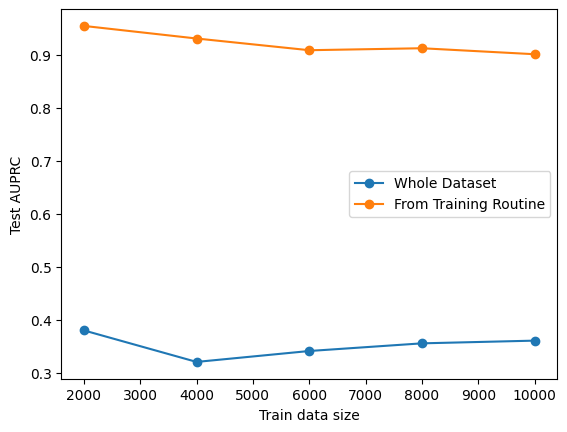

In [ ]:
#Plot test auprc vs size of training data
#Auprc from training routine goes down as the training data increases, but inconclusive auprc changes when testing on full dataset
plt.plot(train_sizes, avg_test_auprcs, label='Whole Dataset', marker='o', linestyle='-')
plt.plot(train_sizes, avg_train_routine_auprcs, label='From Training Routine', marker='o', linestyle='-')
plt.xlabel('Train data size')
plt.ylabel('Test AUPRC')
plt.legend()
plt.show()

In [ ]:
#Small models

#Two level grid search for optimal learning rate 
test_auprcs = []
lrs = [1e-5, 1e-4, 1e-3, 1e-2]
best_auprc = 0
best_lr = 0
for lr in lrs:
    for seed in range(5):
        data_subset = pd.concat([fraud_data, non_fraud_data.sample(n=train_size-len(fraud_data), random_state=seed)]).sample(frac=1, random_state=seed)
        model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(data_subset, lr=lr)
        test_auprcs.append(test_auprc)
        if test_auprc > best_auprc:
            best_auprc = test_auprc
            best_lr = lr
    print(np.mean(np.array(test_auprcs)), lr)

print()
test_auprcs = []
lrs = [best_lr*.3, best_lr*0.7, best_lr*3, best_lr*7]
for lr in lrs:
    for seed in range(5):
        data_subset = pd.concat([fraud_data, non_fraud_data.sample(n=train_size-len(fraud_data), random_state=seed)]).sample(frac=1, random_state=seed)
        model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(data_subset, lr=lr)
        test_auprcs.append(test_auprc)
    print(np.mean(np.array(test_auprcs)), lr)

0.8603885557117394 1e-05
0.8866982500848403 0.0001
0.8907607532666101 0.001
0.8823964458005908 0.01

0.9220887500983505 0.003
0.9242147428195343 0.006999999999999999
0.7493380361443708 0.03
0.6458162299698895 0.07


In [ ]:
#Large Models

#Two level grid search for optimal learning rate 
test_auprcs = []
lrs = [1e-5, 1e-4, 1e-3, 1e-2]
best_auprc = 0
best_lr = 0
for lr in lrs:
    for seed in range(5):
        data_subset = pd.concat([fraud_data, non_fraud_data.sample(n=train_size-len(fraud_data), random_state=seed)]).sample(frac=1, random_state=seed)
        model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(data_subset, lr=lr)
        test_auprcs.append(test_auprc)
        if test_auprc > best_auprc:
            best_auprc = test_auprc
            best_lr = lr
    print(np.mean(np.array(test_auprcs)), lr)

print()
test_auprcs = []
lrs = [best_lr*.3, best_lr*0.7, best_lr*3, best_lr*7]
for lr in lrs:
    for seed in range(5):
        data_subset = pd.concat([fraud_data, non_fraud_data.sample(n=train_size-len(fraud_data), random_state=seed)]).sample(frac=1, random_state=seed)
        model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(data_subset, lr=lr)
        test_auprcs.append(test_auprc)
    print(np.mean(np.array(test_auprcs)), lr)

0.8798111787901732 1e-05
0.89874001683336 0.0001
0.9129904852216518 0.001
0.9090864948508468 0.01

0.9318979721589704 0.003
0.9321335091490838 0.006999999999999999
0.796274044098313 0.03
0.6657812503340302 0.07


In [ ]:
# #Do train/val/test experiment on full dataset for visualization of key metrics
# model, info, aurpcs, aurocs, probs, targets, test_auprc = run_experiment(data, lr=5e-4)
# print(f'Test AUPRC using full dataset in train/val/test experiment: {test_auprc}')

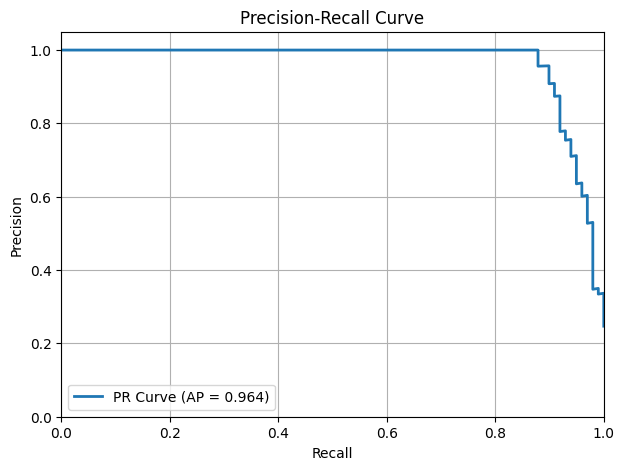

In [27]:
y_true = targets
y_scores = probs

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Compute average precision (area under PR curve)
ap_score = average_precision_score(y_true, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2, label=f"PR Curve (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.legend()
plt.show()

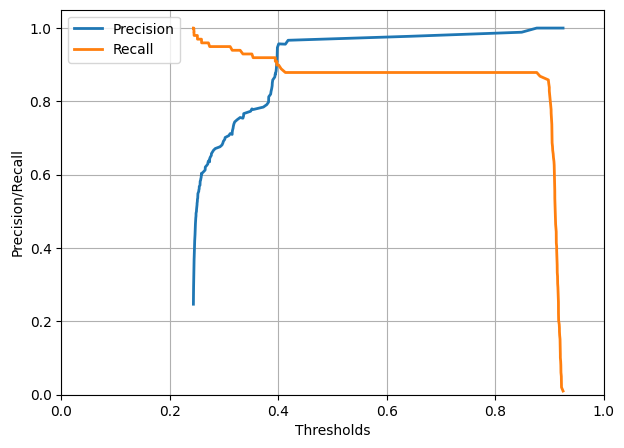

In [ ]:
#Plot precision and recall vs decision threshold. Can use visual to optimize precision vs recall tradeoff and choose optimal decision threshold
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], linewidth=2, label="Precision")
plt.plot(thresholds, recall[:-1], linewidth=2, label="Recall")
plt.xlabel("Thresholds")
plt.ylabel("Precision/Recall")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Find closest precision/recall (General hueristic for choosing a good decision threshold)
min_dist = 1
best_threshold = 0
for i in range(len(thresholds)):
    dist = abs(precision[i] - recall[i])
    if dist < min_dist:
        min_dist = dist
        best_threshold = thresholds[i]
        best_ind = i
print(best_threshold)

0.39729077


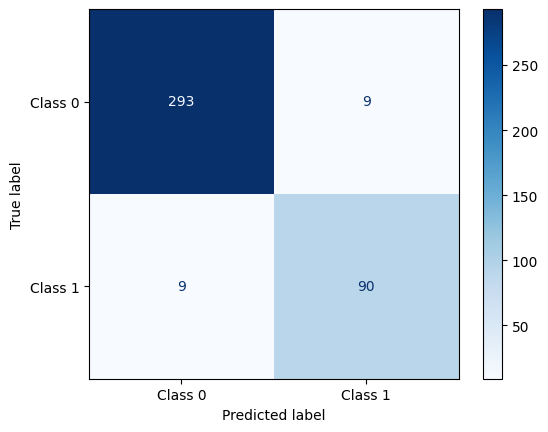

In [ ]:
#Displays confusion matrix from testing results
threshold = best_threshold
cm = confusion_matrix(y_true, (y_scores >= threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

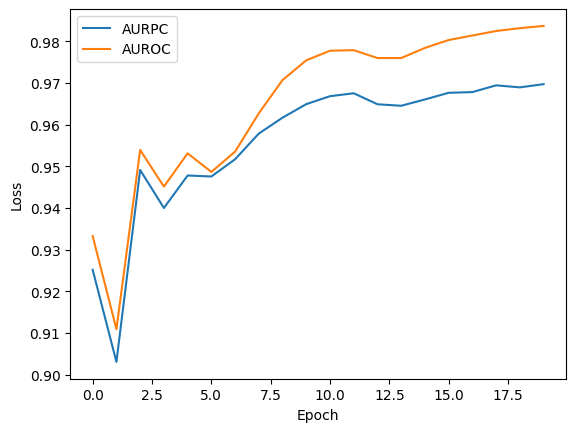

In [ ]:
#Plot AUPRC and AUROC metrics over course of training
plt.plot(range(len(aurpcs)), aurpcs, label='AURPC')
plt.plot(range(len(aurocs)), aurocs, label='AUROC')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
#Tabulate total parameters and training parameters to see model size
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 28,873
Trainable params: 28,873
